In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=sns.load_dataset('Titanic')

In [4]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


**BASIC INFORMATION**

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [7]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
866,1,2,female,27.0,1,0,13.8583,C,Second,woman,False,NaN,Cherbourg,yes,False
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
251,0,3,female,29.0,1,1,10.4625,S,Third,woman,False,G,Southampton,no,False
751,1,3,male,6.0,0,1,12.4750,S,Third,child,False,E,Southampton,yes,False
446,1,2,female,13.0,0,1,19.5000,S,Second,child,False,NaN,Southampton,yes,False


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [9]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**HANDLE MISSING VALUE**

In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
# Fill Age with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill Embarked with mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop Cabin (too many nulls)
df.drop('deck', axis=1, inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

/var/folders/lb/mfzy5mf55gj0dm4z15w7y5940000gn/T/ipykernel_3324/3290968195.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
/var/folders/lb/mfzy5mf55gj0dm4z15w7y5940000gn/T/ipykernel_3324/3290968195.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

In [12]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

**Feature Engineering**

In [13]:
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

In [14]:
df['AgeGroup'] = pd.cut(df['age'], bins=[0,12,20,40,60,80],labels=['Child','Teen','Adult','Middle','Senior'])

In [15]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,FamilySize,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,1,Adult
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,1,Teen
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False,4,NaN
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1,Adult


In [16]:
df.groupby("class")['fare'].max()

class
First     512.3292
Second     73.5000
Third      69.5500
Name: fare, dtype: float64

In [17]:
df.groupby("class")['fare'].min()

class
First     0.0
Second    0.0
Third     0.0
Name: fare, dtype: float64

In [18]:
df["embark_town"].nunique()

3

In [19]:
df.groupby("embark_town")["sex"].value_counts()

embark_town  sex   
Cherbourg    male       95
             female     73
Queenstown   male       41
             female     36
Southampton  male      441
             female    203
Name: count, dtype: int64

**Univariate Analysis**

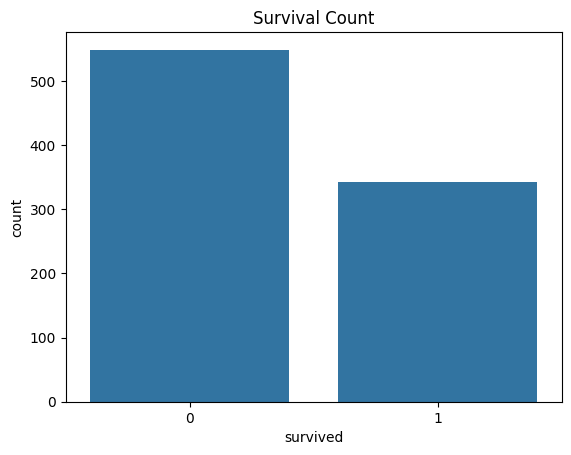

In [20]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

In [21]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

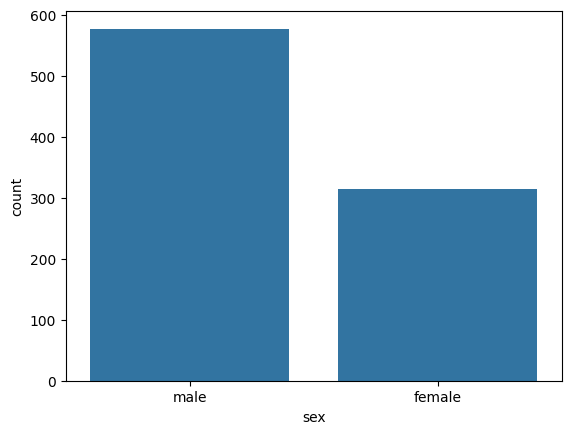

In [22]:
sns.countplot(x='sex', data=df)
plt.show()

In [23]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

**Bivariate Analysis**

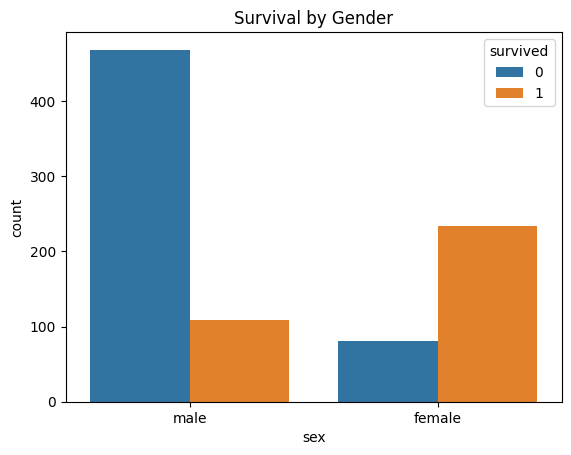

In [24]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

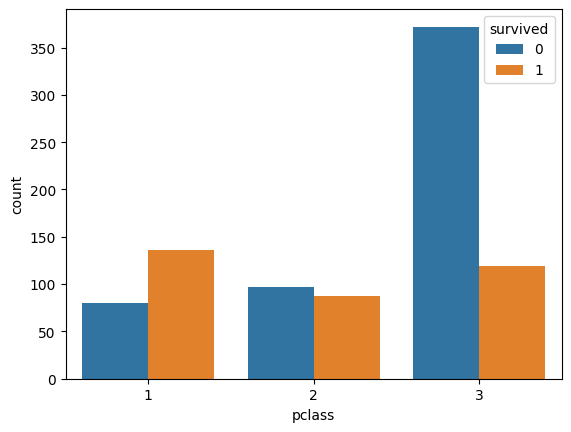

In [25]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.show()

In [26]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

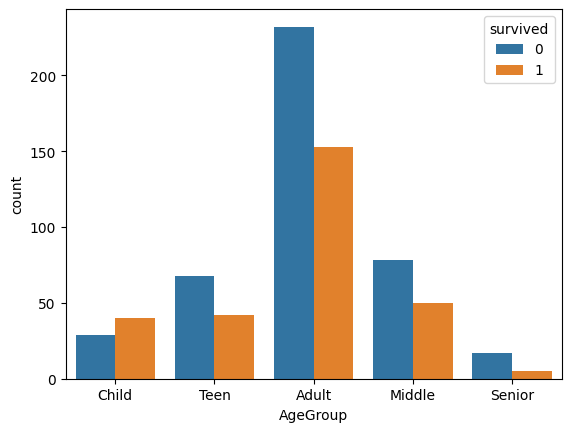

In [27]:
sns.countplot(x='AgeGroup', hue='survived', data=df)
plt.show()

**Multivariate Analysis**

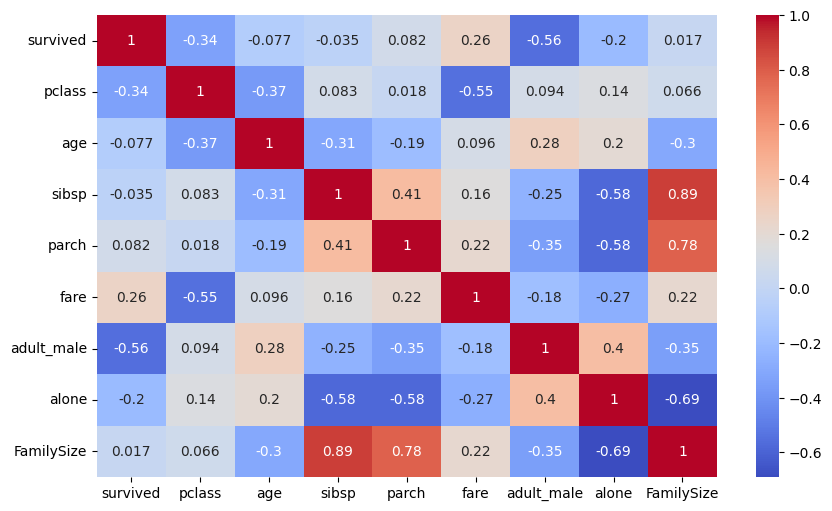

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

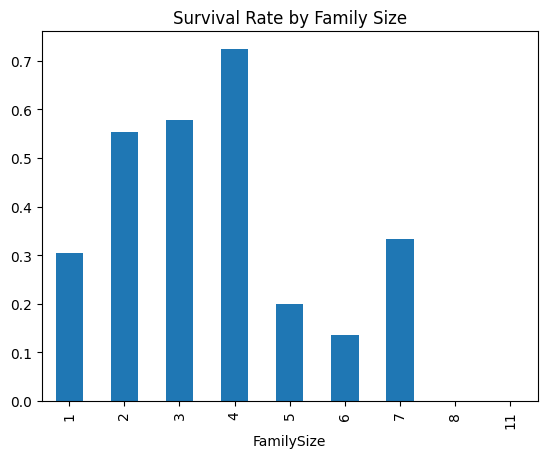

In [29]:
family_survival = df.groupby('FamilySize')['survived'].mean()

family_survival.plot(kind='bar')
plt.title("Survival Rate by Family Size")
plt.show()